## Figure 4b - decomposition of variance for each biophysical property into additvive and epistatic contributions for optimal order models (using the reference-free framework)

Processing Wuhan...
  Raw R2 per order: ['0.7344', '0.8141']
  R2 full: 0.8141
  Delta frac: ['0.9021', '0.0979']  (sum=1.0000)
Processing BA.1...
  Raw R2 per order: ['0.6387', '0.7800', '0.8227']
  R2 full: 0.8227
  Delta frac: ['0.7763', '0.1718', '0.0519']  (sum=1.0000)
Processing BA.4...
  Raw R2 per order: ['0.7982', '0.8345', '0.8798']
  R2 full: 0.8798
  Delta frac: ['0.9072', '0.0413', '0.0514']  (sum=1.0000)
Processing Expression...
  Raw R2 per order: ['0.1479', '0.3455']
  R2 full: 0.3455
  Delta frac: ['0.4279', '0.5721']  (sum=1.0000)
Processing Polyspecificity...
  Raw R2 per order: ['0.2867', '0.3640']
  R2 full: 0.3640
  Delta frac: ['0.7876', '0.2124']  (sum=1.0000)


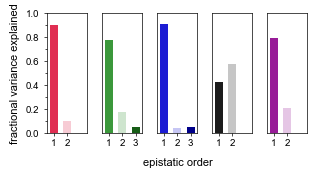

Canvas: 2.60 x 1.2 inches
Figure: 3.40 x 1.90 inches
At 2000 DPI: 6800 x 3800 pixels


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator
from sklearn.preprocessing import PolynomialFeatures
from scipy.special import comb

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

LINEWIDTH  = 0.5
BAR_WIDTH  = 0.6

MAJOR_TICK_WID = 0.5
MINOR_TICK_WID = 0.5
MAJOR_TICK_LEN = 2
MINOR_TICK_LEN = 1.5

LABEL_FONTSIZE      = 8
TICK_LABEL_FONTSIZE = 7

PANEL_WIDTH   = 0.4
PANEL_HEIGHT  = 1.2
PANEL_SPACING = 0.15 

LEFT_MARGIN   = 0.6
RIGHT_MARGIN  = 0.2
TOP_MARGIN    = 0.2
BOTTOM_MARGIN = 0.5

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"
COLOR_EXPR  = "#000000"
COLOR_PSR   = "#8b008b"

def create_color_palette(base_color, n_colors=10):
    rgb = mcolors.hex2color(base_color)
    colors = []
    for i in range(n_colors):
        position = (i / (n_colors - 1)) * 2 - 1
        if position < 0:
            factor = 1 + position
            new_rgb = [c * factor for c in rgb]
        else:
            factor = position
            new_rgb = [c + (1 - c) * factor for c in rgb]
        colors.append(mcolors.rgb2hex(new_rgb))
    return colors

colors_wuhan      = create_color_palette(COLOR_WUHAN)
colors_ba1        = create_color_palette(COLOR_BA1)
colors_ba4        = create_color_palette(COLOR_BA4)
colors_expression = create_color_palette(COLOR_EXPR)
colors_psr        = create_color_palette(COLOR_PSR)

# Palette indices for order 1, 2, 3 bars
COLOR_INDICES = [5, 8, 3]

# ============================================================
# DATA CONFIGURATION
# ============================================================
NUM_MUTATIONS = 13

PHENOTYPE_CONFIG = {
    'Wuhan': {
        'coef_file': '../../epistasis_inference/linear_interaction_models/wuhan/reference-free/model_coeffs/wuhan_raw_2order_full_stat.txt',
        'data_file': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/wuhan_affinity_cleaned.csv',
        'data_col':  'wuhan_log10Kd_mean',
        'max_order': 2,
        'palette':   colors_wuhan,
        'xlabel':    'Wuhan\naffinity',
    },
    'BA.1': {
        'coef_file': '../../epistasis_inference/linear_interaction_models/ba1/reference-free/model_coeffs/ba1_raw_3order_full_stat.txt',
        'data_file': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba1_affinity_cleaned.csv',
        'data_col':  'ba1_log10Kd_mean',
        'max_order': 3,
        'palette':   colors_ba1,
        'xlabel':    'BA.1\naffinity',
    },
    'BA.4': {
        'coef_file': '../../epistasis_inference/linear_interaction_models/ba4/reference-free/model_coeffs/ba4_raw_3order_full_stat.txt',
        'data_file': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba4_affinity_cleaned.csv',
        'data_col':  'ba4_log10Kd_mean',
        'max_order': 3,
        'palette':   colors_ba4,
        'xlabel':    'BA.4\naffinity',
    },
    'Expression': {
        'coef_file': '../../epistasis_inference/linear_interaction_models/expression/reference-free/model_coeffs/expression_raw_2order_full_stat.txt',
        'data_file': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/expression/filtered_expression_replicates.csv',
        'data_col':  'expr_mednorm_mean',
        'max_order': 2,
        'palette':   colors_expression,
        'xlabel':    'Expression',
    },
    'Polyspecificity': {
        'coef_file': '../../epistasis_inference/linear_interaction_models/psr/reference-free/model_coeffs/psr_raw_2order_full_stat.txt',
        'data_file': '../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/polyspecificity/psr_cleaned.csv',
        'data_col':  'mean_EC50_3p',
        'max_order': 2,
        'palette':   colors_psr,
        'xlabel':    'Polyspecificity',
    },
}

def get_order_start_indices(n_muts, max_order):
    num_term_list = [int(comb(n_muts, i)) for i in range(1, max_order + 1)]
    cumsum = list(np.cumsum(num_term_list) + 1)
    return [1] + cumsum

def load_coefs(coef_file, n_total_params):
    coefs = np.zeros(n_total_params + 1)
    with open(coef_file, 'r') as f:
        lines = f.readlines()
    for i, line in enumerate(lines[5:]):
        parts = line.strip().split('\t')
        if len(parts) < 2:
            continue
        coefs[i] = float(parts[1])
    return coefs

def load_data(data_file, data_col, n_muts):
    df = pd.read_csv(data_file).rename(columns={'predicted_phenotype': data_col})
    df['geno'] = df['geno'].astype(str).str.zfill(n_muts)
    df = df.dropna(subset=[data_col])
    geno_matrix = np.array([[int(b) for b in g] for g in df['geno']], dtype=np.float64)
    geno_matrix = 2 * geno_matrix - 1  # {0,1} -> {-1,+1} for stat encoding
    return geno_matrix, df[data_col].values.astype(np.float64)

def compute_delta_variance(coef_file, data_file, data_col, max_order, n_muts):
    n_total_params  = sum(int(comb(n_muts, k)) for k in range(1, max_order + 1))
    order_start_idx = get_order_start_indices(n_muts, max_order)
    coefs           = load_coefs(coef_file, n_total_params)
    genos, phenos   = load_data(data_file, data_col, n_muts)

    poly = PolynomialFeatures(max_order, interaction_only=True)
    X    = poly.fit_transform(genos)

    r2_per_order = []
    for order in range(1, max_order + 1):
        end_idx     = order_start_idx[order]
        phenos_pred = X[:, :end_idx] @ coefs[:end_idx]
        r2          = np.corrcoef(phenos_pred, phenos)[0, 1] ** 2
        r2_per_order.append(r2)

    r2_full = r2_per_order[-1]
    frac    = [r / r2_full for r in r2_per_order]
    delta   = [frac[0]] + [frac[i] - frac[i-1] for i in range(1, max_order)]
    print(f"  Raw R2 per order: {[f'{r:.4f}' for r in r2_per_order]}")
    print(f"  R2 full: {r2_full:.4f}")
    print(f"  Delta frac: {[f'{v:.4f}' for v in delta]}  (sum={sum(delta):.4f})")
    return delta


phenotype_order = ['Wuhan', 'BA.1', 'BA.4', 'Expression', 'Polyspecificity']
results = {}

for phenotype in phenotype_order:
    cfg = PHENOTYPE_CONFIG[phenotype]
    print(f"Processing {phenotype}...")
    delta = compute_delta_variance(
        coef_file=cfg['coef_file'],
        data_file=cfg['data_file'],
        data_col=cfg['data_col'],
        max_order=cfg['max_order'],
        n_muts=NUM_MUTATIONS,
    )
    results[phenotype] = {
        'delta':     delta,
        'max_order': cfg['max_order'],
        'palette':   cfg['palette'],
    }

n_panels   = len(phenotype_order)
canvas_width = n_panels * PANEL_WIDTH + (n_panels - 1) * PANEL_SPACING

fig_width  = LEFT_MARGIN + canvas_width + RIGHT_MARGIN
fig_height = TOP_MARGIN  + PANEL_HEIGHT + BOTTOM_MARGIN

fig = plt.figure(figsize=(fig_width, fig_height))

max_order_global = max(r['max_order'] for r in results.values())

axes = []
for i, phenotype in enumerate(phenotype_order):
    # Compute left edge of this panel in figure-fraction coords
    panel_left = LEFT_MARGIN + i * (PANEL_WIDTH + PANEL_SPACING)
    ax = fig.add_axes([
        panel_left / fig_width,
        BOTTOM_MARGIN / fig_height,
        PANEL_WIDTH / fig_width,
        PANEL_HEIGHT / fig_height,
    ])
    axes.append(ax)

    res     = results[phenotype]
    palette = res['palette']
    delta   = res['delta']
    orders  = list(range(1, res['max_order'] + 1))

    for order_idx, (order, val) in enumerate(zip(orders, delta)):
        color = palette[COLOR_INDICES[order_idx]]
        ax.bar(order, val, width=BAR_WIDTH, color=color, linewidth=0)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(LINEWIDTH)

    ax.set_xlim(0.5, max_order_global + 0.5)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(range(1, res['max_order'] + 1))
    ax.set_xticklabels([str(o) for o in range(1, res['max_order'] + 1)],
                       fontsize=TICK_LABEL_FONTSIZE)
    ax.tick_params(axis='x', which='both',
                   width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                   direction='out')

    if i == 0:
        ax.yaxis.set_major_locator(FixedLocator([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]))
        ax.yaxis.set_minor_locator(FixedLocator([0.1, 0.3, 0.5, 0.7, 0.9]))
        ax.tick_params(axis='y', which='major',
                       width=MAJOR_TICK_WID, length=MAJOR_TICK_LEN,
                       direction='out', labelsize=TICK_LABEL_FONTSIZE)
        ax.tick_params(axis='y', which='minor',
                       width=MINOR_TICK_WID, length=MINOR_TICK_LEN,
                       direction='out', labelleft=False)
        ax.set_ylabel('fractional variance explained', fontsize=LABEL_FONTSIZE)
    else:
        ax.set_yticks([])

    if i == 2:
        ax.set_title('')  

fig.text(
    (LEFT_MARGIN + canvas_width / 2) / fig_width,
    (BOTTOM_MARGIN - 0.35) / fig_height,
    'epistatic order',
    fontsize=LABEL_FONTSIZE, ha='center', va='bottom'
)

# ── Save ─────────────────────────────────────────────────────
plt.savefig('Figure_4b.png', dpi=2000, bbox_inches='tight', transparent=True)

plt.show()

print(f"Canvas: {canvas_width:.2f} x {PANEL_HEIGHT} inches")
print(f"Figure: {fig_width:.2f} x {fig_height:.2f} inches")
print(f"At 2000 DPI: {int(fig_width * 2000)} x {int(fig_height * 2000)} pixels")